In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20, 10)


In [3]:
df=pd.read_csv("../data/price_clean.csv",index_col=0)

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 4838 entries, Niedersachsen to Niedersachsen
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   obj_newlyConst                       4838 non-null   str    
 1   obj_yearConstructed                  4838 non-null   float64
 2   obj_firingTypes                      4098 non-null   str    
 3   obj_cellar                           4838 non-null   str    
 4   obj_houseNumber                      430 non-null    str    
 5   obj_livingSpace                      4838 non-null   float64
 6   geo_krs                              4838 non-null   str    
 7   obj_condition                        3374 non-null   str    
 8   obj_street                           430 non-null    str    
 9   geo_plz                              4838 non-null   float64
 10  obj_noRooms                          4838 non-null   float64
 11  obj_telekomInternetProduc

In [4]:
df.isnull().sum()

obj_newlyConst                            0
obj_yearConstructed                       0
obj_firingTypes                         740
obj_cellar                                0
obj_houseNumber                        4408
obj_livingSpace                           0
geo_krs                                   0
obj_condition                          1464
obj_street                             4408
geo_plz                                   0
obj_noRooms                               0
obj_telekomInternetProductAvailable     301
obj_barrierFree                           0
obj_regio3                                0
obj_livingSpaceRange                      0
obj_telekomUploadSpeed                  933
obj_telekomDownloadSpeed                933
obj_purchasePrice                         0
obj_purchasePrice_per_qm                  0
dtype: int64

In [6]:
# 1. استبعاد الصفوف التي تكون فيها المساحة أو السعر صفر أو أقل
df = df[df['obj_livingSpace'] > 0]
df = df[df['obj_purchasePrice'] > 0]

# 2. إعادة حساب سعر المتر المربع بعد التنظيف
df['obj_purchasePrice_per_qm'] = df['obj_purchasePrice'] / df['obj_livingSpace']

# 3. عرض الوصف الإحصائي للعمود الآن
df['obj_purchasePrice_per_qm'].describe()

count    4838.000000
mean     1961.716071
std       853.653461
min       360.241141
25%      1313.193859
50%      1890.301358
75%      2538.461538
max      4385.316865
Name: obj_purchasePrice_per_qm, dtype: float64

In [7]:
def remove_price_per_qm_outliers_quantiles(df, lower_pct=0.01, upper_pct=0.99):
    df_out = pd.DataFrame()
    
    for key, subdf in df.groupby("obj_regio1"):
        # حساب النسبة 1% والنسبة 99% داخل كل مجموعة
        low_limit = subdf['obj_purchasePrice_per_qm'].quantile(lower_pct)
        high_limit = subdf['obj_purchasePrice_per_qm'].quantile(upper_pct)
        
        # التصفية بناءً على هذه الحدود الثابتة
        reduced_df = subdf[(subdf.obj_purchasePrice_per_qm >= low_limit) & 
                           (subdf.obj_purchasePrice_per_qm <= high_limit)]
        
        df_out = pd.concat([df_out, reduced_df], axis=0)
        
    return df_out

# تطبيق الدالة الجديدة
df = remove_price_per_qm_outliers_quantiles(df)
print(df.shape)   

(4741, 19)


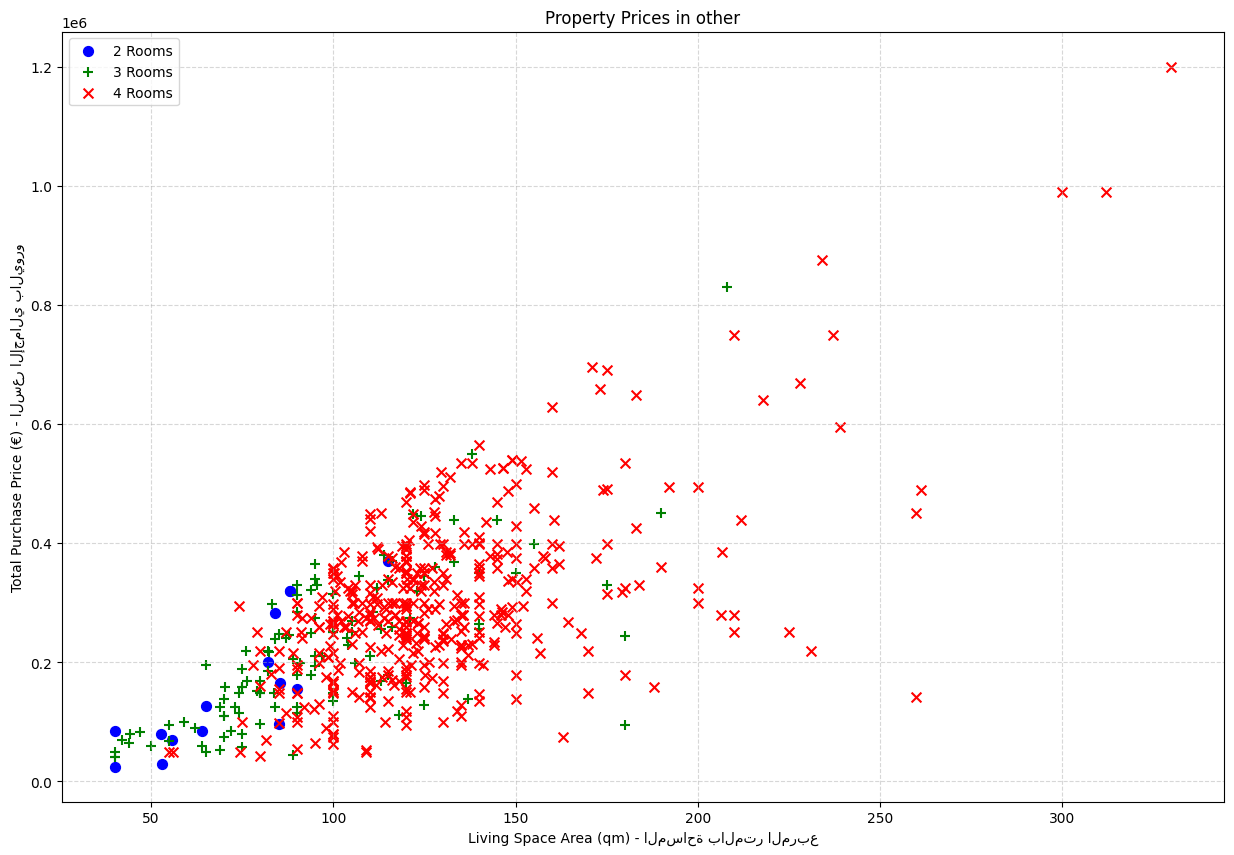

In [8]:
import matplotlib.pyplot as plt

def plot_scatter_chart(df, city_name):
    # الفلترة بناءً على عمود المدينة الصحيح (obj_regio3) وعدد الغرف
    bhk2 = df[(df.obj_regio3 == city_name) & (df.obj_noRooms == 2)]
    bhk3 = df[(df.obj_regio3 == city_name) & (df.obj_noRooms == 3)]
    bhk4 = df[(df.obj_regio3 == city_name) & (df.obj_noRooms == 4)] # أضفنا 4 غرف لأنها شائعة في ألمانيا

    # تحديد حجم الرسمة
    plt.figure(figsize=(15, 10))

    # رسم الشقق ذات الغرفتين (باللون الأزرق)
    plt.scatter(
        bhk2.obj_livingSpace,
        bhk2.obj_purchasePrice,
        color='blue',
        label='2 Rooms',
        s=50
    )

    # رسم الشقق ذات الـ 3 غرف (باللون الأخضر وعلامة +)
    plt.scatter(
        bhk3.obj_livingSpace,
        bhk3.obj_purchasePrice,
        marker='+',
        color='green',
        label='3 Rooms',
        s=50
    )
    
    # رسم الشقق ذات الـ 4 غرف (باللون الأحمر وعلامة x) إن وجدت
    plt.scatter(
        bhk4.obj_livingSpace,
        bhk4.obj_purchasePrice,
        marker='x',
        color='red',
        label='4 Rooms',
        s=50
    )

    # تسمية المحاور والعنوان بشكل صحيح ومناسب لداتاتك
    plt.xlabel("Living Space Area (qm) - المساحة بالمتر المربع")
    plt.ylabel("Total Purchase Price (€) - السعر الإجمالي باليورو")
    plt.title(f"Property Prices in {city_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# استدعاء الدالة لمدينة Laatzen مع كتابة الحرف الأول كبيراً كما هو في الجدول
plot_scatter_chart(df, "other")

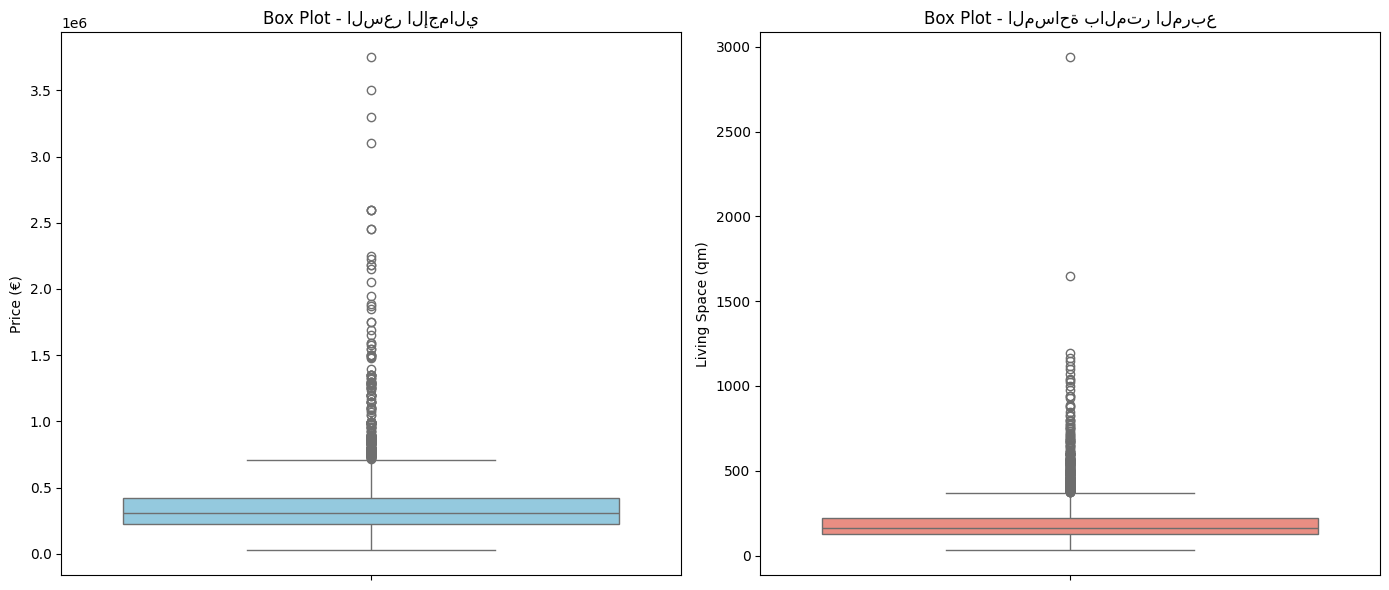

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# إنشاء مساحة لرسمتين بجانب بعضهما
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. المخطط الصندوقي لأسعار العقارات
sns.boxplot(y=df['obj_purchasePrice'], color='skyblue', ax=ax1)
ax1.set_title('Box Plot - السعر الإجمالي')
ax1.set_ylabel('Price (€)')

# 2. المخطط الصندوقي لمساحات العقارات
sns.boxplot(y=df['obj_livingSpace'], color='salmon', ax=ax2)
ax2.set_title('Box Plot - المساحة بالمتر المربع')
ax2.set_ylabel('Living Space (qm)')

plt.tight_layout()
plt.show()

📊 فحص عمود [obj_purchasePrice]:
   - الحدود الطبيعية: من -80,000.0 إلى 720,000.0
   - عدد القيم الشاذة المكتشفة: 246 صف
   - نسبة الشواذ في كامل الداتا: 5.08%
--------------------------------------------------
📊 فحص عمود [obj_livingSpace]:
   - الحدود الطبيعية: من -25.0 إلى 375.0
   - عدد القيم الشاذة المكتشفة: 272 صف
   - نسبة الشواذ في كامل الداتا: 5.62%
--------------------------------------------------


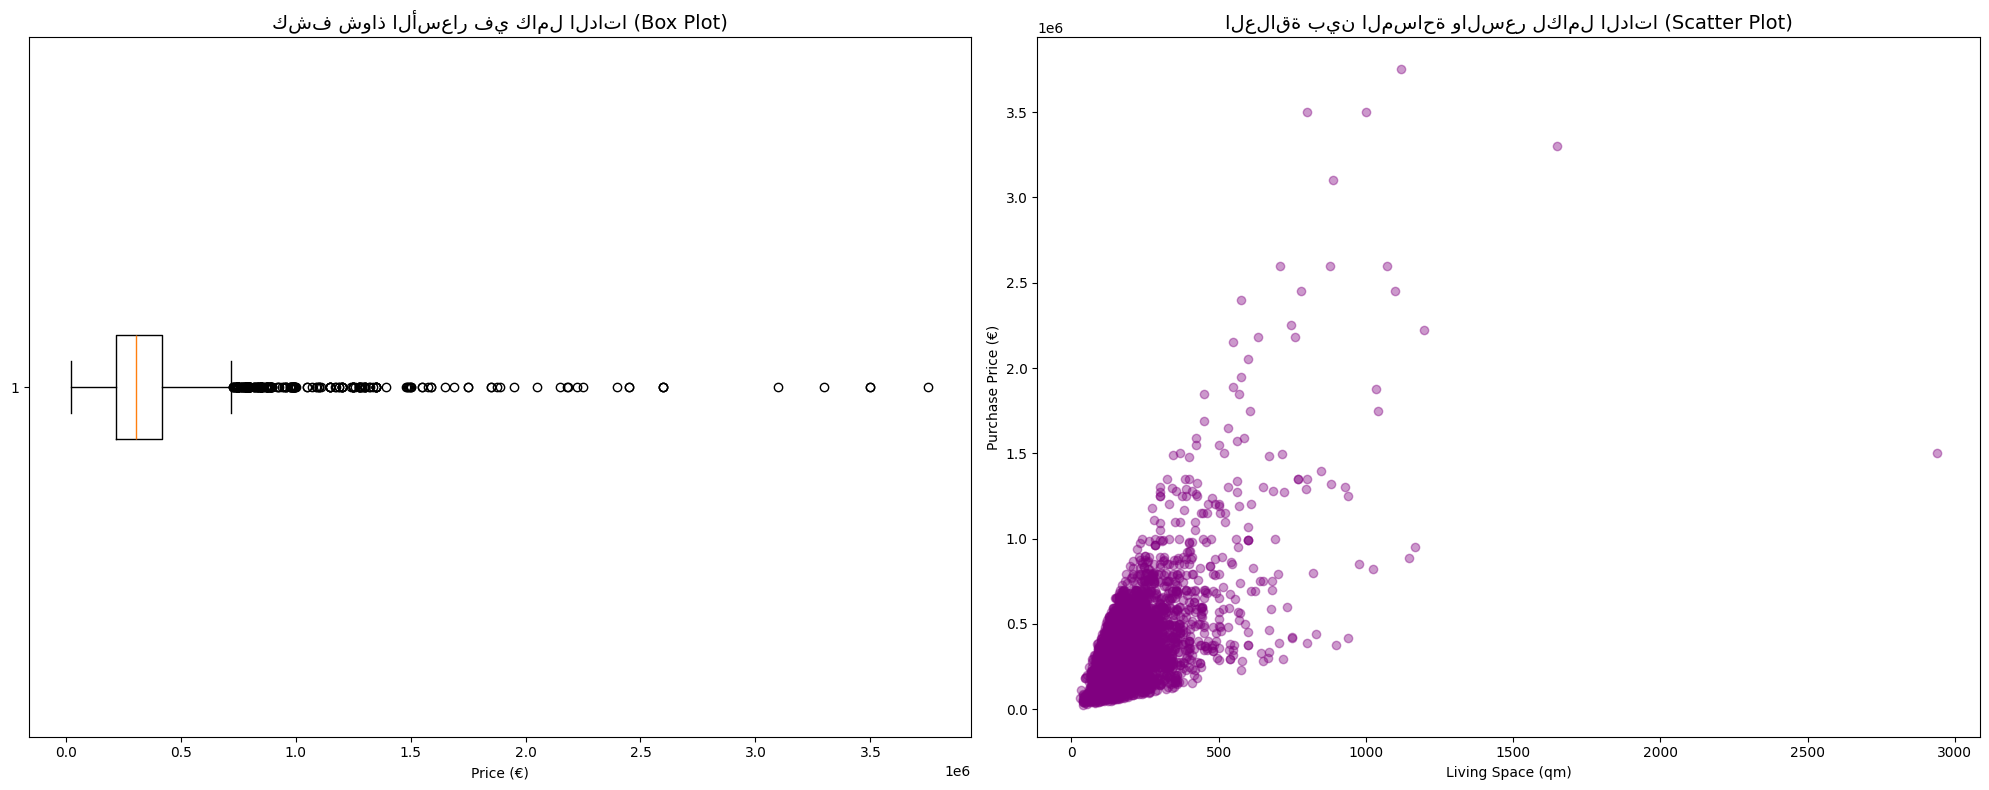

In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib

# ضبط حجم الرسم البياني ليكون كبيراً وواضحاً
matplotlib.rcParams["figure.figsize"] = (20, 10)

# 1. قراءة ملف البيانات الخاص بكِ
df = pd.read_csv("price_clean.csv")

# 2. حساب واكتشاف الشواذ في كامل الداتا (رقمياً)
def check_all_dataset_outliers(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column_name] < lower_limit) | (dataframe[column_name] > upper_limit)]
    
    print(f"📊 فحص عمود [{column_name}]:")
    print(f"   - الحدود الطبيعية: من {lower_limit:,.1f} إلى {upper_limit:,.1f}")
    print(f"   - عدد القيم الشاذة المكتشفة: {len(outliers)} صف")
    print(f"   - نسبة الشواذ في كامل الداتا: {((len(outliers) / len(dataframe)) * 100):.2f}%")
    print("-" * 50)

# تشغيل الفحص الرقمي
check_all_dataset_outliers(df, 'obj_purchasePrice')
check_all_dataset_outliers(df, 'obj_livingSpace')


# 3. الرسم البياني باستخدام matplotlib فقط (بدون seaborn)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# الرسمة الأولى: المخطط الصندوقي (Box Plot) للسعر الإجمالي
ax1.boxplot(df['obj_purchasePrice'], vert=False) # vert=False يجعله أفقياً ليسهل قراءته
ax1.set_title('كشف شواذ الأسعار في كامل الداتا (Box Plot)', fontsize=14)
ax1.set_xlabel('Price (€)')

# الرسمة الثانية: الـ Scatter Plot العام للعلاقة بين المساحة والسعر
ax2.scatter(df['obj_livingSpace'], df['obj_purchasePrice'], alpha=0.4, color='purple')
ax2.set_title('العلاقة بين المساحة والسعر لكامل الداتا (Scatter Plot)', fontsize=14)
ax2.set_xlabel('Living Space (qm)')
ax2.set_ylabel('Purchase Price (€)')

plt.tight_layout()
plt.show()

In [11]:
# 1. إلغاء الشواذ بناءً على الحدود الطبيعية التي ظهرت في الفحص
df_clean_all = df[(df['obj_purchasePrice'] <= 720000) & (df['obj_livingSpace'] <= 375)].copy()

# 2. طباعة حجم البيانات قبل وبعد التنظيف لرؤية الفرق
print(f"📊 حجم البيانات الأصلي (قبل التنظيف): {df.shape}")
print(f"✨ حجم البيانات الجديد (بعد إلغاء الشواذ): {df_clean_all.shape}")
print(f"🗑️ عدد العقارات الشاذة التي تم حذفها: {len(df) - len(df_clean_all)}")

📊 حجم البيانات الأصلي (قبل التنظيف): (4838, 20)
✨ حجم البيانات الجديد (بعد إلغاء الشواذ): (4442, 20)
🗑️ عدد العقارات الشاذة التي تم حذفها: 396


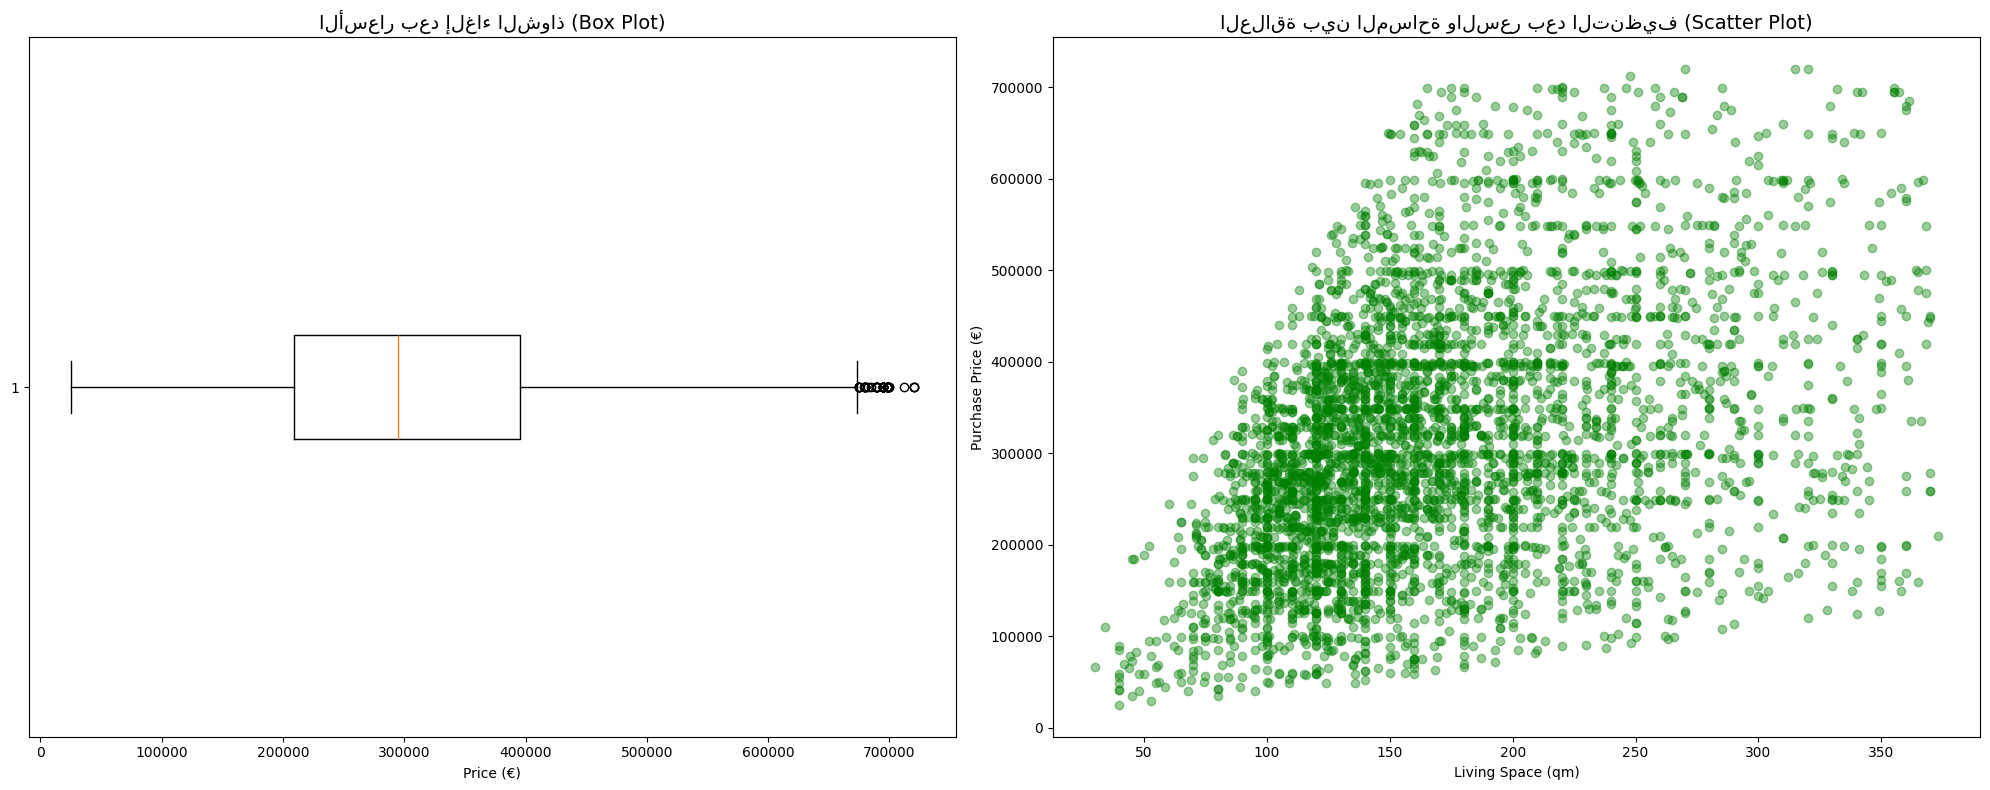

In [12]:
# رسم البيانات بعد حذف الشواذ للتأكد من النتيجة
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1. الـ Box Plot بعد التنظيف
ax1.boxplot(df_clean_all['obj_purchasePrice'], vert=False)
ax1.set_title('الأسعار بعد إلغاء الشواذ (Box Plot)', fontsize=14)
ax1.set_xlabel('Price (€)')

# 2. الـ Scatter Plot بعد التنظيف
ax2.scatter(df_clean_all['obj_livingSpace'], df_clean_all['obj_purchasePrice'], alpha=0.4, color='green')
ax2.set_title('العلاقة بين المساحة والسعر بعد التنظيف (Scatter Plot)', fontsize=14)
ax2.set_xlabel('Living Space (qm)')
ax2.set_ylabel('Purchase Price (€)')

plt.tight_layout()
plt.show()